In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
df = pd.read_csv("C:/Users/shris/Downloads/salary-prediction-ml/data/DataScience_salaries_2024.csv")
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2021,MI,FT,Data Scientist,30400000,CLP,40038,CL,100,CL,L
1,2021,MI,FT,BI Data Analyst,11000000,HUF,36259,HU,50,US,L
2,2020,MI,FT,Data Scientist,11000000,HUF,35735,HU,50,HU,L
3,2021,MI,FT,ML Engineer,8500000,JPY,77364,JP,50,JP,S
4,2022,SE,FT,Lead Machine Learning Engineer,7500000,INR,95386,IN,50,IN,L


In [3]:
df.isnull().sum()
df = df.dropna()

In [4]:
df = df[[
    "experience_level",
    "employment_type",
    "job_title",
    "company_location",
    "remote_ratio",
    "salary_in_usd"
]]

In [5]:
le = LabelEncoder()

for col in ["experience_level", "employment_type", "job_title", "company_location"]:
    df[col] = le.fit_transform(df[col])

In [6]:
X = df.drop("salary_in_usd", axis=1)
y = df["salary_in_usd"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [8]:
y_pred = model.predict(X_test)

In [9]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 39770.53145969364
R2 Score: 0.3338053000195803


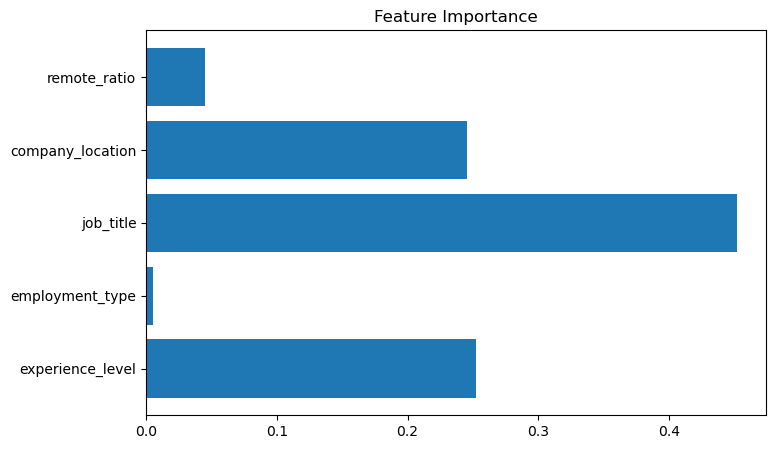

In [10]:
importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(8,5))
plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

In [11]:
plt.savefig("C:/Users/shris/Downloads/salary-prediction-ml/outputs/Feature Importance")

<Figure size 640x480 with 0 Axes>